This notebook examines how softmax temperature scaling affects model performance and its relationship to human behavioural performance

**Prerequisites:** **Data inputs:** Trained Transformer model checkpoints under `processed_data/ito_models/` and validation puzzles from `processed_data/puzzle_data_original.csv`.

**Generating scripts:** `run_transformer.py` to train the models.


# Model Performance Analysis: Temperature Effects
## Evaluating transformer model performance with varying temperature on validation set

This notebook evaluates the standard 2DPE trained model (after 4000 epochs) on the 108 validation puzzles,
varying the temperature parameter and analyzing performance separately for binary, ternary, and quaternary puzzles.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lstnn.dataset import get_dataset
import lstnn.transformer_main as transformer_main
import torch

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load validation dataset and model configuration

Defines model configuration, temperature sweep range, and dataset paths.


In [ ]:
# Data and model configuration
data_dir = "../processed_data/"
validation_data_path = f"{data_dir}puzzle_data_original.csv"

# Model hyperparameters (matching the trained model)
model_label = 'BERT'
pe = '2dpe'
petype = 'absolute2d'
n_layer = 4
dropout = 0.0
wdecay = 0.0
attnhead = 1
hidden_size = 160
curriculum = 'All'
learning_rate = 0.0001
training_acc_cutoff = 0.0
cutoff_length = 0
epoch = 4000

# Seeds used for training
seeds = [2235, 6312, 6068, 9742, 8880, 2197, 669,
         6256, 3309, 2541, 8643, 7785, 195, 6914, 29]

# Temperature values to test
temperatures = [0.0001, 0.001, .01, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 10.0, 100.0, 1000.0]

device = 'cpu'

print(f"Loading validation data from: {validation_data_path}")
print(f"Number of seeds: {len(seeds)}")
print(f"Temperature values to test: {temperatures}")

Loading validation data from: ../processed_data/puzzle_data_original.csv
Number of seeds: 15
Temperature values to test: [0.0001, 0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 10.0, 100.0, 1000.0]


In [ ]:
# Load validation dataset
LST_puzzle_ds = get_dataset(validation_data_path)
dataloader = torch.utils.data.DataLoader(LST_puzzle_ds, batch_size=108, shuffle=False)

# Get puzzle metadata (puzzle conditions)
puzzle_df = pd.read_csv(validation_data_path)
print(f"Total validation puzzles: {len(puzzle_df)}")
print(f"\nPuzzle type distribution:")
print(puzzle_df['condition'].value_counts().sort_index())

Total validation puzzles: 108

Puzzle type distribution:
condition
Binary        36
Quaternary    36
Ternary       36
Name: count, dtype: int64


## Define evaluation function

In [ ]:
def evaluate_model_with_temperature(model, dataloader, temperature=1.0, device='cpu'):
    """
    Evaluate model accuracy with a specific temperature parameter.
    
    Args:
        model: Trained transformer model
        dataloader: DataLoader with validation data
        temperature: Temperature parameter for softmax
        device: Device to run evaluation on
    
    Returns:
        predictions: Array of predicted labels
        targets: Array of true labels
        accuracy: Overall accuracy
    """
    model.eval()
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for batch in dataloader:
            test_features = batch[0]  # Input features
            test_targets = batch[1]   # Target labels
            
            # Flatten inputs (batch, 4, 4, 5) -> (batch, 16, 5)
            test_features = torch.flatten(test_features, start_dim=1, end_dim=2)
            test_features = test_features.to(device)
            
            # Forward pass with temperature
            # Note: model may return tuple for some positional encodings
            model_output = model(test_features, temperature=temperature)
            
            # Handle both single output and tuple output
            if isinstance(model_output, tuple):
                outputs = model_output[0]  # First element is the actual output
            else:
                outputs = model_output
            
            # Get predictions
            predictions = torch.argmax(outputs, dim=1)
            
            # Handle targets - convert from one-hot if needed
            if len(test_targets.shape) > 1 and test_targets.shape[1] > 1:
                # One-hot encoded targets
                targets_idx = torch.argmax(test_targets, dim=1)
            else:
                # Already class indices
                targets_idx = test_targets
            
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets_idx.numpy())
    
    predictions = np.concatenate(all_predictions)
    targets = np.concatenate(all_targets)
    accuracy = np.mean(predictions == targets)
    
    return predictions, targets, accuracy

## Evaluate models across all seeds and temperatures

Loads the trained experimentor model for evaluation at different temperatures.


In [ ]:
# Build model path string
modelname = f"model-{model_label}_" \
            f"pe-{pe}_" \
            f"nl-{n_layer}_" \
            f"do-{dropout}_" \
            f"wd-{wdecay}_" \
            f"at-{attnhead}_" \
            f"hs-{hidden_size}_" \
            f"curr-{curriculum}_" \
            f"lr-{learning_rate}_" \
            f"co-{training_acc_cutoff}_" \
            f"col-{cutoff_length}/"

print(f"Model path: {data_dir}{modelname}")

# Store results
results = []

# Evaluate each seed
for seed_idx, seed in enumerate(seeds):
    print(f"\nEvaluating seed {seed_idx+1}/{len(seeds)}: {seed}")
    
    # Load model
    torch.manual_seed(seed)
    model = transformer_main.Transformer(
        nblocks=n_layer,
        nhead=attnhead,
        dropout=dropout,
        embedding_dim=hidden_size,
        positional_encoding=petype
    )
    model = model.to(device=torch.device(device))
    
    #model_file = f"{results_dir}{modelname}s-{seed}_e-{epoch}.pt"
    model_file = f"{data_dir}ito_models/{modelname}s-{seed}_e-{epoch}.pt"
    model.load_state_dict(torch.load(model_file, map_location=torch.device(device)))
    
    # Evaluate at each temperature
    for temp in temperatures:
        predictions, targets, accuracy = evaluate_model_with_temperature(
            model, dataloader, temperature=temp, device=device
        )
        
        # Calculate accuracy by puzzle type
        for puzzle_idx in range(len(predictions)):
            condition = puzzle_df.iloc[puzzle_idx]['condition']
            puzzle_type = condition  # Binary, Ternary, or Quaternary
            
            results.append({
                'seed': seed,
                'seed_idx': seed_idx,
                'temperature': temp,
                'puzzle_idx': puzzle_idx,
                'puzzle_type': puzzle_type,
                'condition': condition,
                'prediction': predictions[puzzle_idx],
                'target': targets[puzzle_idx],
                'correct': predictions[puzzle_idx] == targets[puzzle_idx]
            })
        
        # print(f"  Temperature {temp:.2f}: Accuracy = {accuracy:.4f}")

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(f"\nTotal evaluations: {len(results_df)}")
print(f"Shape: {results_df.shape}")

Model path: ../processed_data/model-BERT_pe-2dpe_nl-4_do-0.0_wd-0.0_at-1_hs-160_curr-All_lr-0.0001_co-0.0_col-0/

Evaluating seed 1/15: 2235


/tmp/ipykernel_2356646/1565305442.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_file, map_location=torch.device(device)))
.../e


Evaluating seed 2/15: 6312

Evaluating seed 3/15: 6068

Evaluating seed 4/15: 9742

Evaluating seed 5/15: 8880

Evaluating seed 6/15: 2197

Evaluating seed 7/15: 669

Evaluating seed 8/15: 6256

Evaluating seed 9/15: 3309

Evaluating seed 10/15: 2541

Evaluating seed 11/15: 8643

Evaluating seed 12/15: 7785

Evaluating seed 13/15: 195

Evaluating seed 14/15: 6914

Evaluating seed 15/15: 29

Total evaluations: 25920
Shape: (25920, 9)


## Aggregate results by temperature and puzzle type

In [ ]:
# Calculate mean accuracy across seeds for each temperature and puzzle type
accuracy_by_temp_type = results_df.groupby(['temperature', 'puzzle_type', 'seed'])['correct'].mean().reset_index()
accuracy_by_temp_type.columns = ['temperature', 'puzzle_type', 'seed', 'accuracy']

# Calculate summary statistics
summary_stats = accuracy_by_temp_type.groupby(['temperature', 'puzzle_type'])['accuracy'].agg(['mean', 'std', 'sem']).reset_index()
summary_stats.columns = ['temperature', 'puzzle_type', 'mean_accuracy', 'std_accuracy', 'sem_accuracy']

print("\nSummary statistics:")
display(summary_stats.head())


Summary statistics:


,temperature,puzzle_type,mean_accuracy,std_accuracy,sem_accuracy
0,0.0001,Binary,0.487037,0.144668,0.037353
1,0.0001,Quaternary,0.520370,0.140258,0.036214
2,0.0001,Ternary,0.477778,0.152579,0.039396
3,0.0010,Binary,0.487037,0.148057,0.038228
4,0.0010,Quaternary,0.512963,0.131915,0.034060


## Visualize results

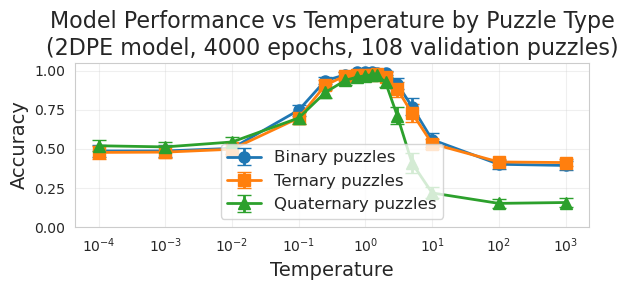

In [ ]:
# Plot 1: Accuracy vs Temperature by Puzzle Type
fig, ax = plt.subplots(figsize=(6, 3))

# Define colors for each puzzle type
colors = {'Binary': '#1f77b4', 'Ternary': '#ff7f0e', 'Quaternary': '#2ca02c'}
markers = {'Binary': 'o', 'Ternary': 's', 'Quaternary': '^'}

for puzzle_type in ['Binary', 'Ternary', 'Quaternary']:
    data = summary_stats[summary_stats['puzzle_type'] == puzzle_type]
    ax.errorbar(data['temperature'], data['mean_accuracy'], 
                yerr=data['sem_accuracy'],
                marker=markers[puzzle_type], 
                color=colors[puzzle_type],
                label=f'{puzzle_type} puzzles',
                linewidth=2, markersize=8, capsize=5)

ax.set_xlabel('Temperature', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_title('Model Performance vs Temperature by Puzzle Type\n(2DPE model, 4000 epochs, 108 validation puzzles)', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

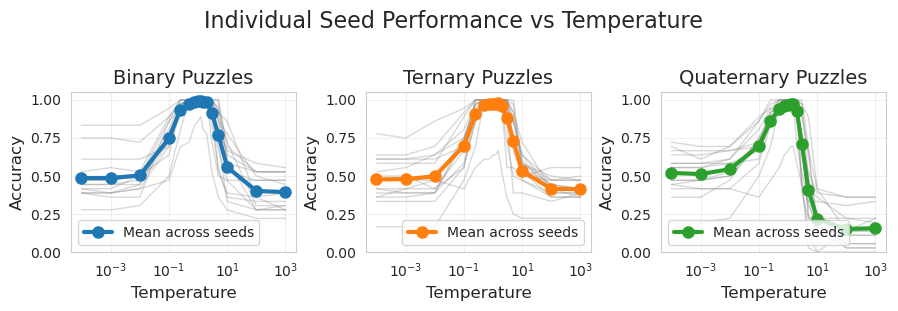

In [ ]:
# Plot 2: Individual seed trajectories
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for idx, puzzle_type in enumerate(['Binary', 'Ternary', 'Quaternary']):
    ax = axes[idx]
    data = accuracy_by_temp_type[accuracy_by_temp_type['puzzle_type'] == puzzle_type]
    
    # Plot individual seeds
    for seed in seeds:
        seed_data = data[data['seed'] == seed]
        ax.plot(seed_data['temperature'], seed_data['accuracy'], 
                alpha=0.3, color='gray', linewidth=1)
    
    # Plot mean
    mean_data = summary_stats[summary_stats['puzzle_type'] == puzzle_type]
    ax.plot(mean_data['temperature'], mean_data['mean_accuracy'],
            color=colors[puzzle_type], linewidth=3, marker='o', markersize=8,
            label='Mean across seeds')
    
    ax.set_xlabel('Temperature', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'{puzzle_type} Puzzles', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_ylim([0, 1.05])

plt.suptitle('Individual Seed Performance vs Temperature', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

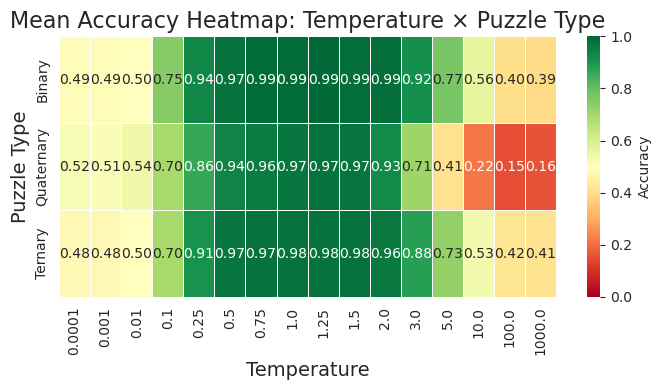

In [ ]:
# Plot 3: Heatmap of accuracy by temperature and puzzle type
pivot_data = summary_stats.pivot(index='puzzle_type', columns='temperature', values='mean_accuracy')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Accuracy'},
            linewidths=0.5, ax=ax)
ax.set_xlabel('Temperature', fontsize=14)
ax.set_ylabel('Puzzle Type', fontsize=14)
ax.set_title('Mean Accuracy Heatmap: Temperature × Puzzle Type', fontsize=16)

plt.tight_layout()
# plt.savefig(f'{results_dir}temperature_analysis_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Statistical analysis

Statistical comparison of accuracy at each temperature relative to the default (t=1.0).


In [ ]:
# Find optimal temperature for each puzzle type
print("\n" + "="*60)
print("OPTIMAL TEMPERATURE BY PUZZLE TYPE")
print("="*60)

for puzzle_type in ['Binary', 'Ternary', 'Quaternary']:
    type_data = summary_stats[summary_stats['puzzle_type'] == puzzle_type]
    best_temp = type_data.loc[type_data['mean_accuracy'].idxmax()]
    print(f"\n{puzzle_type} puzzles:")
    print(f"  Optimal temperature: {best_temp['temperature']:.2f}")
    print(f"  Accuracy at optimal: {best_temp['mean_accuracy']:.4f} ± {best_temp['sem_accuracy']:.4f}")
    
    # Compare to temperature = 1.0
    baseline = type_data[type_data['temperature'] == 1.0].iloc[0]
    improvement = best_temp['mean_accuracy'] - baseline['mean_accuracy']
    print(f"  Accuracy at T=1.0: {baseline['mean_accuracy']:.4f} ± {baseline['sem_accuracy']:.4f}")
    print(f"  Improvement: {improvement:.4f} ({improvement/baseline['mean_accuracy']*100:.2f}%)")


OPTIMAL TEMPERATURE BY PUZZLE TYPE

Binary puzzles:
  Optimal temperature: 1.25
  Accuracy at optimal: 0.9926 ± 0.0074
  Accuracy at T=1.0: 0.9907 ± 0.0093
  Improvement: 0.0019 (0.19%)

Ternary puzzles:
  Optimal temperature: 1.50
  Accuracy at optimal: 0.9778 ± 0.0222
  Accuracy at T=1.0: 0.9759 ± 0.0241
  Improvement: 0.0019 (0.19%)

Quaternary puzzles:
  Optimal temperature: 1.25
  Accuracy at optimal: 0.9741 ± 0.0204
  Accuracy at T=1.0: 0.9685 ± 0.0222
  Improvement: 0.0056 (0.57%)


In [ ]:
# Overall accuracy across all puzzle types
print("\n" + "="*60)
print("OVERALL ACCURACY (ALL PUZZLE TYPES)")
print("="*60)

overall_accuracy = results_df.groupby(['temperature', 'seed'])['correct'].mean().reset_index()
overall_accuracy["correct"] = overall_accuracy["correct"] * 100
overall_summary = overall_accuracy.groupby('temperature')['correct'].agg(['mean', 'std', 'sem']).reset_index()
overall_summary.columns = ['temperature', 'mean_accuracy', 'std_accuracy', 'sem_accuracy']

print("\n", overall_summary.to_string())

best_overall = overall_summary.loc[overall_summary['mean_accuracy'].idxmax()]
print(f"\nBest overall temperature: {best_overall['temperature']:.2f}")
print(f"Accuracy: {best_overall['mean_accuracy']:.4f} ± {best_overall['sem_accuracy']:.4f}")


OVERALL ACCURACY (ALL PUZZLE TYPES)

     temperature  mean_accuracy  std_accuracy  sem_accuracy
0        0.0001      49.506173     12.738354      3.289029
1        0.0010      49.320988     12.271160      3.168400
2        0.0100      51.543210     12.361652      3.191765
3        0.1000      71.481481     12.749566      3.291924
4        0.2500      90.185185     10.596551      2.736018
5        0.5000      96.049383      9.262345      2.391527
6        0.7500      97.407407      7.772107      2.006749
7        1.0000      97.839506      7.117910      1.837836
8        1.2500      98.086420      6.662869      1.720345
9        1.5000      97.901235      7.133379      1.841831
10       2.0000      95.802469      9.448248      2.439527
11       3.0000      83.703704     15.867834      4.097057
12       5.0000      63.641975     18.220037      4.704393
13      10.0000      43.703704      8.444294      2.180307
14     100.0000      32.345679      4.058210      1.047825
15    1000.0000  

# Comparison to human data

In [ ]:
from scipy.stats import spearmanr

human_df = pd.read_csv('../processed_data/human_behaviour.csv')
human_by_puzzle_acc = human_df.groupby(["LST_id"]).mean(numeric_only=True).reset_index()["accuracy"][0:108].values

puzzle_summary = results_df.groupby(["puzzle_idx", "temperature"]).mean(numeric_only=True).reset_index()

human_comparison = []

for temp in temperatures:
    ann_by_puzzle_acc = puzzle_summary.loc[puzzle_summary.temperature == temp, "correct"].values
    r, p = spearmanr(ann_by_puzzle_acc, human_by_puzzle_acc)
    df = pd.DataFrame()
    df["rho"] = [r]
    df["pval"] = p
    df["diff"] = np.sum(ann_by_puzzle_acc - human_by_puzzle_acc)
    df["temperature"] = temp
    human_comparison.append(df)

human_comparison = pd.concat(human_comparison)

In [ ]:
from statsmodels.stats.multitest import multipletests
# FDR correction for human_comparison p-values
reject, pvals_fdr, _, _ = multipletests(human_comparison["pval"], method="fdr_bh")
human_comparison["pval_fdr"] = pvals_fdr
display(human_comparison)

,rho,pval,diff,temperature,pval_fdr
0,-0.009925,9.187992e-01,-36.508333,0.0001,9.322851e-01
0,0.008272,9.322851e-01,-36.708333,0.0010,9.322851e-01
0,-0.015201,8.759172e-01,-34.308333,0.0100,9.322851e-01
0,0.279116,3.441538e-03,-12.775000,0.1000,4.588717e-03
0,0.363811,1.086825e-04,7.425000,0.2500,3.477840e-04
0,0.324900,6.019512e-04,13.758333,0.5000,1.205939e-03
0,0.310194,1.086566e-03,15.225000,0.7500,1.851763e-03
0,0.296998,1.800371e-03,15.691667,1.0000,2.618721e-03
0,0.308577,1.157352e-03,15.958333,1.2500,1.851763e-03
0,0.266025,5.389685e-03,15.758333,1.5000,6.633458e-03


In [ ]:

table = human_comparison[["temperature", "diff", "rho", "pval_fdr"]]
table[["diff", "rho"]] = table[["diff", "rho"]].round(2)
table[["pval_fdr"]] = table[["pval_fdr"]].round(3)
display(table)

/tmp/ipykernel_2356646/813777978.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table[["diff", "rho"]] = table[["diff", "rho"]].round(2)
/tmp/ipykernel_2356646/813777978.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  table[["pval_fdr"]] = table[["pval_fdr"]].round(3)


,temperature,diff,rho,pval_fdr
0,0.0001,-36.51,-0.01,0.932
0,0.0010,-36.71,0.01,0.932
0,0.0100,-34.31,-0.02,0.932
0,0.1000,-12.77,0.28,0.005
0,0.2500,7.43,0.36,0.000
0,0.5000,13.76,0.32,0.001
0,0.7500,15.23,0.31,0.002
0,1.0000,15.69,0.30,0.003
0,1.2500,15.96,0.31,0.002
0,1.5000,15.76,0.27,0.007


/tmp/ipykernel_2356646/2953747826.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


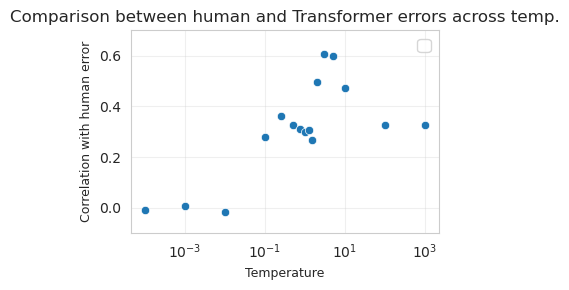

/tmp/ipykernel_2356646/2953747826.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


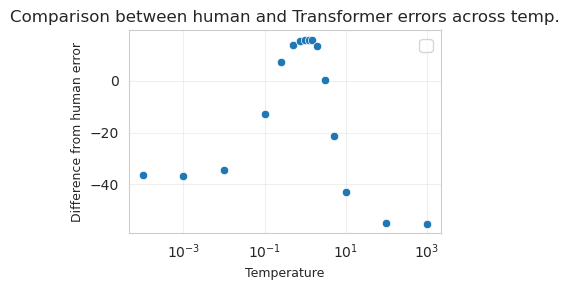

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))
ax = sns.scatterplot(data=human_comparison, x="temperature", y="rho")
ax.set_xlabel('Temperature', fontsize=9)
ax.set_ylabel('Correlation with human error', fontsize=9)
ax.set_title('Comparison between human and Transformer errors across temp.', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_ylim([-0.10, 0.7])

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3))
ax = sns.scatterplot(data=human_comparison, x="temperature", y="diff")
ax.set_xlabel('Temperature', fontsize=9)
ax.set_ylabel('Difference from human error', fontsize=9)
ax.set_title('Comparison between human and Transformer errors across temp.', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.show()

# Publication plot

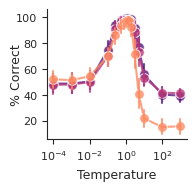

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
#

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("ticks")
# create figure
fig, axs = plt.subplot_mosaic("""
                              B
                              """,
                              figsize=(1.85, 1.8),
                              constrained_layout=True)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlabel('Response Time (s)', fontsize=9)
ax.set_ylabel('Attention Score', fontsize=9, labelpad=-0)
sns.despine(ax=ax)

ax = axs["B"]
plot = results_df.groupby(["seed", "temperature", "condition"]).mean(numeric_only=True).reset_index()
plot["correct"] = plot["correct"] * 100
sns.lineplot(data=plot, 
             y="correct", 
             x="temperature", 
             hue="condition", hue_order=["Binary", "Ternary", "Quaternary"],
             palette="magma", 
             ax=ax, 
             legend=False,
             marker="o",
             markersize=7, alpha=.79,
             markers=True, err_style="bars", errorbar="ci",
             sizes=3)

#ax.plot([1,1], [0, plot.loc[plot.temperature==1, "correct"].mean()], zorder=0, color="grey", linestyle='--', alpha=0.5)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlabel('Temperature', fontsize=9)
ax.set_ylabel('% Correct', fontsize=9, labelpad=-5)
ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-4, 1e-2, 1e0, 1e2])
ax.set_ylim([6, 106])
sns.despine(ax=ax)
plt.show()

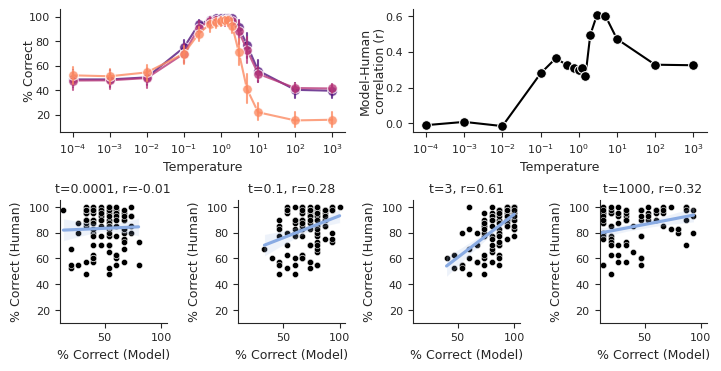

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
#

plt.rcParams['svg.fonttype'] = 'none'
sns.set_style("ticks")
# create figure
fig, axs = plt.subplot_mosaic("""
                              AABB
                              CDEF
                              """,
                              figsize=(7.1, 3.6),
                              constrained_layout=True)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlabel('Response Time (s)', fontsize=9)
ax.set_ylabel('Attention Score', fontsize=9, labelpad=-0)
sns.despine(ax=ax)

ax = axs["A"]
plot = results_df.groupby(["seed", "temperature", "condition"]).mean(numeric_only=True).reset_index()
plot["correct"] = plot["correct"] * 100
sns.lineplot(data=plot, 
             y="correct", 
             x="temperature", 
             hue="condition", hue_order=["Binary", "Ternary", "Quaternary"],
             palette="magma", 
             ax=ax, 
             legend=False,
             marker="o",
             markersize=7, alpha=.79,
             markers=True, err_style="bars", errorbar="ci",
             sizes=3)

#ax.plot([1,1], [0, plot.loc[plot.temperature==1, "correct"].mean()], zorder=0, color="grey", linestyle='--', alpha=0.5)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlabel('Temperature', fontsize=9)
ax.set_ylabel('% Correct', fontsize=9, labelpad=-5)
ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3])
ax.set_ylim([6, 106])
sns.despine(ax=ax)

ax = axs["B"]
sns.lineplot(data=human_comparison, 
             y="rho", 
             x="temperature",
             color="k", 
             ax=ax, 
             legend=False,
             marker="o",
             markersize=7, alpha=1,
             markeredgecolor='w',
             markers=True, err_style="bars", errorbar="ci",
             sizes=3)

#ax.plot([1,1], [0, human_comparison.loc[human_comparison.temperature==1, "rho"].mean()], zorder=0, color="grey", linestyle='--', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlabel('Temperature', fontsize=9)
ax.set_ylabel('Model-Human\ncorrelation (r)', fontsize=9, labelpad=-1)
ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3])
sns.despine(ax=ax)

for a, temp in zip(["C", "D", "E", "F"], [0.0001, 0.1, 3, 1000]):
    ann_by_puzzle_acc = puzzle_summary.loc[puzzle_summary.temperature == temp, "correct"].values
    r, p = spearmanr(ann_by_puzzle_acc, human_by_puzzle_acc)
    ax = axs[a]
    data = pd.DataFrame()
    data["% Correct (Model)"] = ann_by_puzzle_acc * 100
    data["% Correct (Human)"] = human_by_puzzle_acc * 100

    # scatter plot
    sns.scatterplot(data=data, x="% Correct (Model)", y="% Correct (Human)", color="k", legend=False, ax=ax, s=20)
    sns.regplot(data=data, x="% Correct (Model)", y="% Correct (Human)", color=(0.537, 0.671, 0.890), scatter=False, ax=ax)
    ax.set_ylim([10, 105])
    ax.set_xlim([10, 105])
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_xlabel('% Correct (Model)', fontsize=9)
    ax.set_ylabel('% Correct (Human)', fontsize=9)
    ax.set_title(f"t={temp}, r={r.round(2)}", fontsize=9)
    sns.despine()
plt.show()